# Flexible beams

Notebook `python/Notebooks/tutorialFlexibleBeams.ipynb`.

Two simple planar beams and the utility functions that build them: the `ObjectBeamGeometricallyExact2D`, a shear
deformable Reissner-Timoshenko beam, and the thin cable `ObjectANCFCable2D`, a large deformation Bernoulli-Euler beam.
Both beams are highly flexible, 2 m long, 5 mm high and 10 mm wide, made of steel. The shear deformable beam is
clamped to the ground, the cable is clamped to a moving ground. The outputs below each cell are those of the last run.

In [1]:
import exudyn as exu
from exudyn.utilities import *   #includes itemInterface, rigidBodyUtilities, pi, sin, cos, sqrt and SmoothStep
from exudyn.beams import GenerateBeamElementsAlongLine
from exudyn.interactive import ShowImage
import numpy as np

SC = exu.SystemContainer()
mbs = SC.AddSystem()

The beam parameters, the discretization and the geometry of both beams:

In [2]:
numberOfElements = 16
L = 2                     # length of beam
E = 2e11                  # steel
rho = 7800
h = 0.005                 # height of rectangular beam element in m
b = 0.01                  # width of rectangular beam element in m
A = b*h                   # cross sectional area of beam element in m^2
I = b*h**3/12             # second moment of area of beam element in m^4
nu = 0.3                  # Poisson's ratio

EI = E*I
EA = E*A
rhoA = rho*A
rhoI = rho*I
ks = 10*(1+nu)/(12+11*nu) # shear correction factor
G = E/(2*(1+nu))          # shear modulus
GA = ks*G*A               # shear stiffness of beam

g = [0,-9.81,0]           # gravity vector
positionStart = [0,0,0]
positionEnd = [L,0,0]

A beam is made of 2D rigid body nodes (or slope nodes) and beam elements, with constraints and loads. The utility
function `GenerateBeamElementsAlongLine` does this for straight beams: discretization, constraints and gravity. It
takes a **beam template**, which holds the beam parameters - here of the geometrically exact beam - and fills in the
element lengths and the nodes. `groundConstraintsStart=[1,1,1]` clamps the first node:

In [3]:
beamTemplate = Beam2D(nodeNumbers=[-1,-1], #filled by the function
                      massPerLength=rhoA,
                      crossSectionInertia=rhoI,
                      bendingStiffness=EI,
                      axialStiffness=EA,
                      shearStiffness=GA,
                      bendingDamping=0.02*EI,
                      visualization=VObjectBeamGeometricallyExact2D(drawHeight=h))

beamData = GenerateBeamElementsAlongLine(mbs, positionStart, positionEnd, numberOfElements, beamTemplate,
                                         gravity=g, groundConstraintsStart=[1,1,1])

The same for the ANCF cable elements (Bernoulli-Euler), without constraints:

In [4]:
cableTemplate = Cable2D(nodeNumbers=[-1,-1],
                        massPerLength=rhoA,
                        bendingStiffness=EI,
                        axialStiffness=EA,
                        bendingDamping=0.02*EI,
                        visualization=VCable2D(drawHeight=h))

cableData = GenerateBeamElementsAlongLine(mbs, positionStart, positionEnd, numberOfElements, cableTemplate,
                                          gravity=g)

A ground and two markers, to attach the first node of the cable with a generic joint:

In [5]:
oGround = mbs.CreateGround(referencePosition=[0,0,0])
mGround = mbs.AddMarker(MarkerBodyRigid(bodyNumber=oGround, localPosition=[0,0,0]))
mCable = mbs.AddMarker(MarkerNodeRigid(nodeNumber=cableData['nodes'][0]))

The cable shall move relative to the ground: a user function prescribes the relative rotation and the (corotated)
translation in the joint, smoothly in time:

In [6]:
def UFoffset(mbs, t, itemNumber, offsetUserFunctionParameters):
    x = SmoothStep(t, 2, 4, 0, 0.5)   #translate in local joint coordinates
    phi = SmoothStep(t, 5, 10, 0, pi) #rotates frame of mGround
    return [x, 0,0,0,0,phi]

The joint fixes the two translations in the plane and the rotation about $z$ - for 2D objects, only these three may
be constrained:

In [7]:
oJoint = mbs.AddObject(GenericJoint(markerNumbers=[mGround, mCable],
                                    constrainedAxes=[1,1,0, 0,0,1],
                                    offsetUserFunction=UFoffset,
                                    visualization=VGenericJoint(axesRadius=0.01, axesLength=0.02)))
sTip = mbs.AddSensor(SensorNode(nodeNumber=beamData['nodes'][-1], storeInternal=True,
                                outputVariableType=exu.OutputVariableType.Position))

As before: assemble, and the simulation settings - a sparse linear solver and the modified Newton method for a
faster simulation - and some visualization settings:

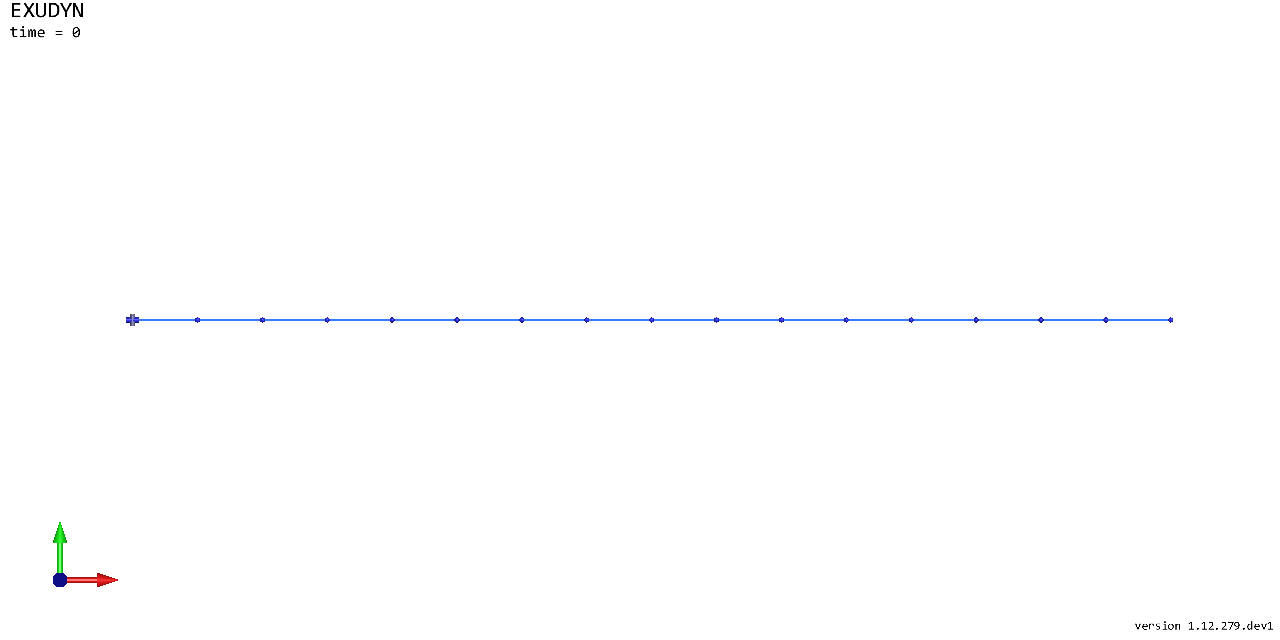

In [8]:
mbs.Assemble()

simulationSettings = exu.SimulationSettings()
tEnd = 10
stepSize = 0.005
simulationSettings.timeIntegration.numberOfSteps = int(tEnd/stepSize)
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.solution.file.writePeriod = 0.005
simulationSettings.linearSolver.solverType = exu.LinearSolverType.EigenSparse
simulationSettings.timeIntegration.newton.useModifiedNewton = True #for faster simulation

SC.visualizationSettings.nodes.defaultSize = 0.01
SC.visualizationSettings.nodes.drawNodesAsPoint = False #show beam nodes
SC.visualizationSettings.bodies.beams.crossSectionFilled = True
SC.visualizationSettings.loads.show = False  #the gravity loads of the nodes
SC.visualizationSettings.general.showSolverInformation = False
image = ShowImage(SC, size=[1280,640]) #the reference configuration

Solve in time. In a script, `SC.renderer.Start()` before and `SC.renderer.Stop()` after it show the motion, and
`mbs.SolutionViewer()` shows it again afterwards, as the simulation may be faster than you can follow. The lower beam
is clamped at its left end; the support of the upper beam is translated and rotated:

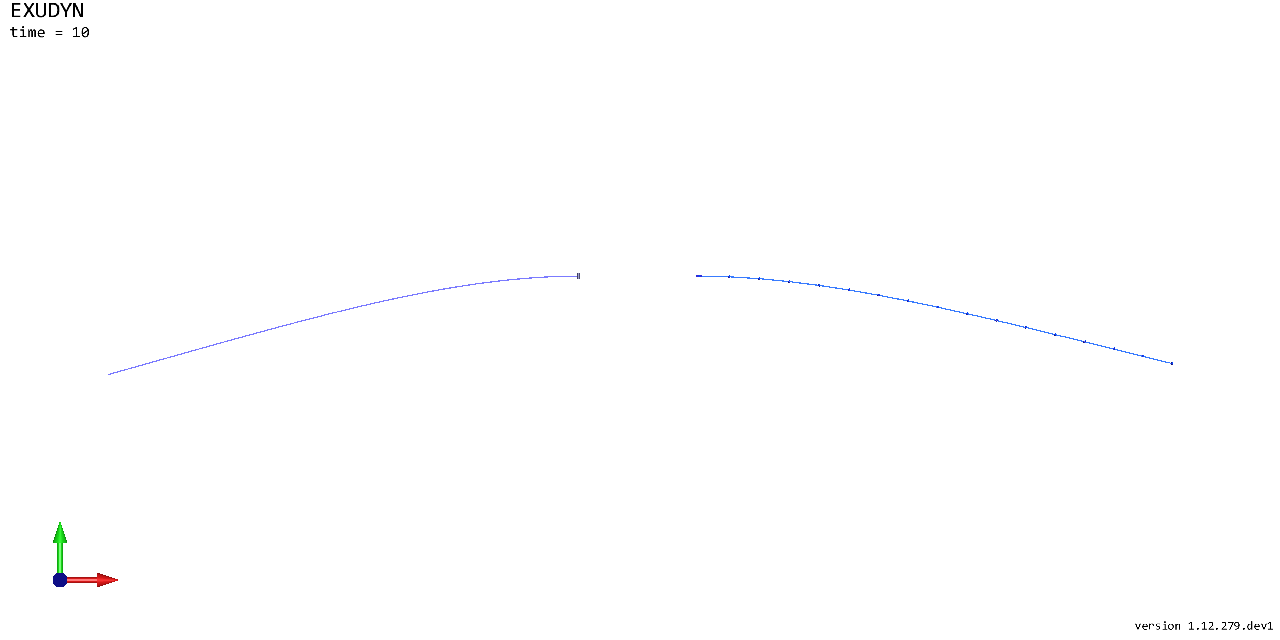

In [9]:
mbs.SolveDynamic(simulationSettings)
image = ShowImage(SC, size=[1280,640]) #the state at t=10 s

The tip of the clamped beam over time:

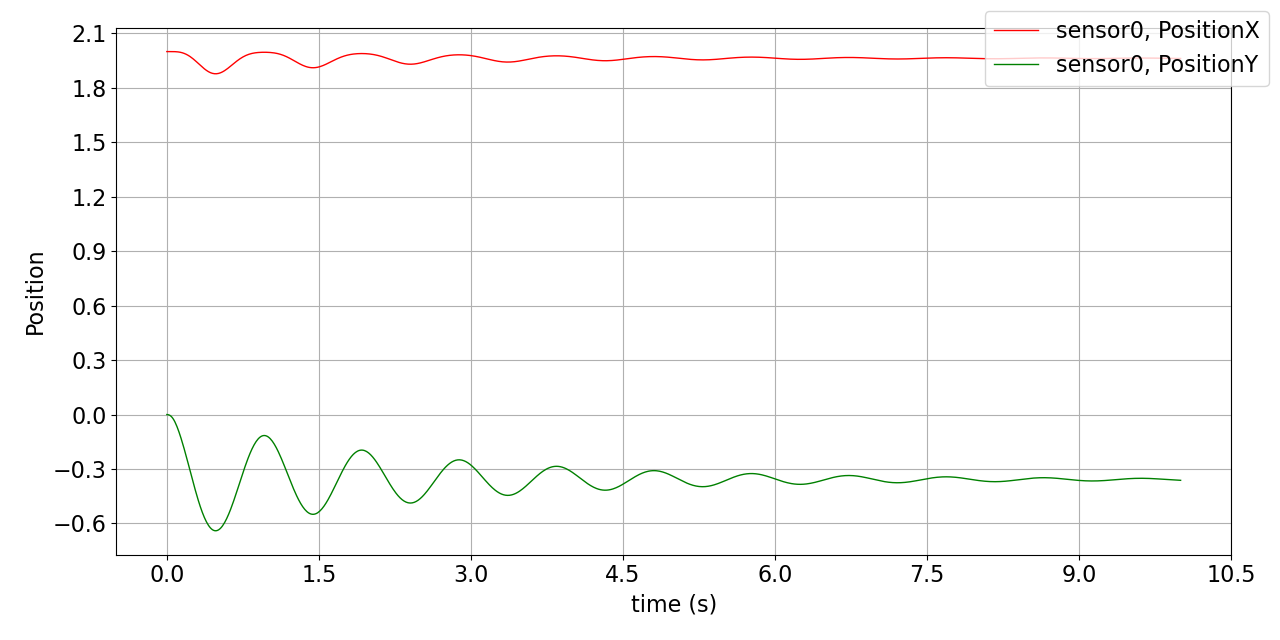

In [10]:
mbs.PlotSensor(sTip, components=[0,1], closeAll=True)

This is a starting point for beam models; further examples show more advanced functions, e.g. curved beams or
reeving systems, a sliding joint, axially moving beams and contact between beams and sheaves.